# **Atividade Prática**
<font size=3>

- **Tema:** comparação e seleção de modelos.
- **Prazo de entrega:** 09 de Junho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

## **Enunciado:**
<font size=3>

Você atua como cientista de dados em um hospital. Sua equipe testou vários algoritmos para prever doenças cardíacas, e as acurácias médias parecem muito próximas. \
O modelos foram:
1. **Regressão Logística:** Linear, alto viés potencial (baseline).
2. **KNN (k-Nearest Neighbors):** Não-linear, sensível à escala.
3. **Árvore de Decisão:** Alta variância, baixo viés.
4. **Random Forest:** Ensemble (busca reduzir a variância da árvore).

Seu chefe perguntou: "Qual modelo devemos colocar em produção com segurança?". Sua missão é usar estatística no dataset [`breast-cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html). Para isso, realize os seguintes passos:


### **1º Passo:**
<font size=3>
    
1. Carregue o dataset;
2. Realize um pré-processamento básico (tratamento de nulos se houver, [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) é obrigatório para o KNN e Regressão Logística);
3. Implemente um loop de validação cruzada com [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) com a estrafificação [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) para 10 *folds* e `random_state` fixo;
4. Armazene a acurácia de cada modelo em cada um dos 10 folds.

In [29]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dataset = load_breast_cancer()

x = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = dataset.target

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
models = {
    "Regressão Logística": Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42, max_iter=10000))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
    "Árvore de Decisão": Pipeline([('model', DecisionTreeClassifier(random_state=42))]),
    "Random Forest": Pipeline([('model', RandomForestClassifier(random_state=42))])
}


In [30]:


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
models = {
    "Regressão Logística": Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42, max_iter=10000))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
    "Árvore de Decisão": Pipeline([('model', DecisionTreeClassifier(random_state=42))]),
    "Random Forest": Pipeline([('model', RandomForestClassifier(random_state=42))])
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, x, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores


df_results = pd.DataFrame(results)

print("\nAcurácia por fold para cada modelo:")
print(df_results.round(4))

print("\nResumo das Acurácias")
for model_name in results.keys():
    mean_score = df_results[model_name].mean()
    std_score = df_results[model_name].std()
    print(f"{model_name}: {mean_score:.4f} ({std_score:.4f})")


Acurácia por fold para cada modelo:
   Regressão Logística     KNN  Árvore de Decisão  Random Forest
0               0.9825  0.9825             0.9123         0.9474
1               0.9825  0.9825             0.9298         0.9825
2               0.9474  0.9649             0.9649         0.9649
3               0.9474  0.9474             0.8947         0.9123
4               0.9825  0.9474             0.8947         0.9474
5               0.9474  0.9474             0.9649         0.9649
6               1.0000  1.0000             0.9298         0.9649
7               0.9825  0.9825             0.9123         0.9474
8               0.9825  0.9649             0.9298         0.9298
9               1.0000  0.9821             0.9286         1.0000

Resumo das Acurácias
Regressão Logística: 0.9754 (0.0206)
KNN: 0.9701 (0.0186)
Árvore de Decisão: 0.9262 (0.0245)
Random Forest: 0.9561 (0.0252)


### **2º Passo:**
<font size=3>
    
1. Gere um **Boxplot** comparando as distribuições das acurácias dos 4 modelos. Visualmente, existe um vencedor claro? **Escreva** em uma **célula _markdown_**;
2. Aplique o **Teste de t** par a par com **correção de Bonferroni**;
3. Algum modelo é estatisticamente superior aos outros? Ou existem "empates técnicos"? **Escreva** em uma **célula _markdown_**.

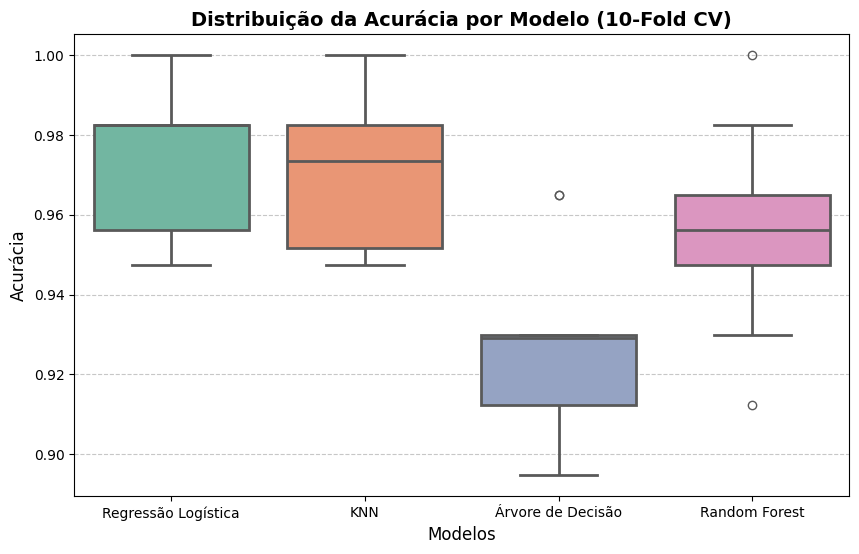

ANÁLISE ESTATÍSTICA (TESTE T PAREADO)
Número de comparações: 6
Alfa original: 0.05
Alfa corrigido (Bonferroni): 0.00833


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_results, palette="Set2", linewidth=2)
plt.title("Distribuição da Acurácia por Modelo (10-Fold CV)", fontsize=14, fontweight='bold')
plt.ylabel("Acurácia", fontsize=12)
plt.xlabel("Modelos", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

alpha_original = 0.05
model_names = list(df_results.columns)

pairs = list(combinations(model_names, 2))
num_comparisons = len(pairs)

alpha_bonferroni = alpha_original / num_comparisons

print(f"Teste T pareado)")
print(f"Número de comparações: {num_comparisons}")
print(f"Alfa original: {alpha_original}")
print(f"Alfa corrigido (Bonferroni): {alpha_bonferroni:.5f}")


In [32]:
statistical_summary = []

for mod1, mod2 in pairs:

    t_stat, p_value = stats.ttest_rel(df_results[mod1], df_results[mod2])
    

    significant = p_value < alpha_bonferroni
    
    statistical_summary.append({
        "Comparação": f"{mod1} vs {mod2}",
        "Estatística t": round(t_stat, 4),
        "p-value": round(p_value, 6),
        "Rejeita H0?": "Sim (Diferente)" if significant else "Não (Empate Técnico)"
    })

df_stat = pd.DataFrame(statistical_summary)
print(df_stat.to_string(index=False))

                              Comparação  Estatística t  p-value          Rejeita H0?
              Regressão Logística vs KNN         1.1568 0.277136 Não (Empate Técnico)
Regressão Logística vs Árvore de Decisão         4.2226 0.002231      Sim (Diferente)
    Regressão Logística vs Random Forest         2.4004 0.039872 Não (Empate Técnico)
                KNN vs Árvore de Decisão         4.6122 0.001268      Sim (Diferente)
                    KNN vs Random Forest         1.9133 0.087997 Não (Empate Técnico)
      Árvore de Decisão vs Random Forest        -3.7722 0.004402      Sim (Diferente)


### **3º Passo:**
<font size=3>

1. Selecione a **Árvore de Decisão** e a **Regressão Logística**;
2. Utilize a técnica de decomposição de erro (MSE das probabilidades) vista em aula;
3. Gere o gráfico de barras comparando $Viés^2$ e $Variância$ para estes dois modelos;
4. Qual modelo sofre mais de *Overfitting*? Isso condiz com a teoria? **Escreva** em uma **célula _markdown_**.


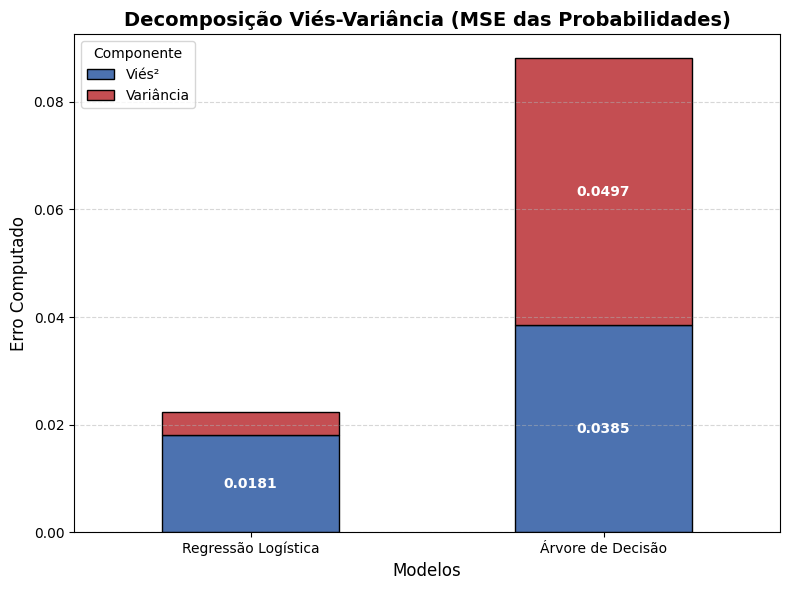

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

dataset = load_breast_cancer()
X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_bootstraps = 200
n_samples = len(X_test)

predictions_lr = np.zeros((n_bootstraps, n_samples))
predictions_dt = np.zeros((n_bootstraps, n_samples))

for i in range(n_bootstraps):

    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    

    X_boot_scaled = scaler.fit_transform(X_boot)
    lr = LogisticRegression(max_iter=10000, random_state=42)
    lr.fit(X_boot_scaled, y_boot)
    predictions_lr[i, :] = lr.predict_proba(X_test_scaled)[:, 1]
    

    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_boot, y_boot)
    predictions_dt[i, :] = dt.predict_proba(X_test)[:, 1]

expected_lr = np.mean(predictions_lr, axis=0)
expected_dt = np.mean(predictions_dt, axis=0)

bias2_lr = np.mean((expected_lr - y_test) ** 2)
bias2_dt = np.mean((expected_dt - y_test) ** 2)

var_lr = np.mean(np.var(predictions_lr, axis=0))
var_dt = np.mean(np.var(predictions_dt, axis=0))

df_decomp = pd.DataFrame({
    'Componente': ['Viés²', 'Variância'],
    'Regressão Logística': [bias2_lr, var_lr],
    'Árvore de Decisão': [bias2_dt, var_dt]
}).set_index('Componente')

ax = df_decomp.T.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#4C72B0', '#C44E52'], edgecolor='black')
plt.title("Decomposição Viés-Variância (MSE das Probabilidades)", fontsize=14, fontweight='bold')
plt.ylabel("Erro Computado", fontsize=12)
plt.xlabel("Modelos", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y_coord = p.get_xy() 
    if height > 0.01:
        ax.annotate(f'{height:.4f}', (x + width/2, y_coord + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
Árvore de Decisão é o modelo que mais sofre de overfitting pois a varincia é mais dominante nesse modelo do que no outro olhando para a plotagem vemos uma variancia de 0.0497 
muitas vezes maior do que do modelo de regressao o que pode levar a previsoes instaveis do modelo mudando a depender do folder que for usado para treina-lo, quando analisamos pelo boxplot a acuracia é de 89% 
nos foldes 3 e 4 ja nos outros fica na casa dos 96% essa ocilação gera um alto desvio padrao se comparado aos demais modelos logo mostrando mais uma vez sua instabilidade, o algoritmo de regressao logistica teve o 
menor vies e quase nao variou durante os testes e sua acuracia tambem foi bem alta de 97%.

entao sim condiz com a teoria vista nos notebooks 12 e 10 
